In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Download NLTK resources for preprocessing
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Libraries imported and resources downloaded successfully!")

Matplotlib is building the font cache; this may take a moment.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


Libraries imported and resources downloaded successfully!


In [5]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Dataset Head:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


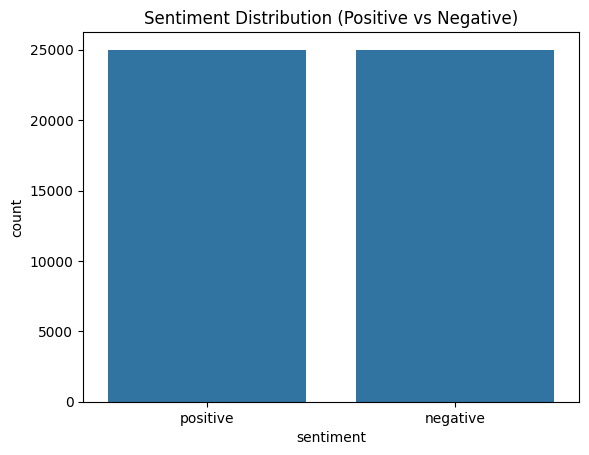

In [7]:
# Load the dataset
# Replace 'IMDB Dataset.csv' with your actual filename
df = pd.read_csv('IMDB Dataset.csv') 

# Display the first 5 rows to understand the structure
print("Dataset Head:")
print(df.head())

# Data Understanding: Check distribution of classes
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# Visualize the distribution
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution (Positive vs Negative)')
plt.show()

In [8]:
# Initialize Lemmatizer and Stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()
    
    # 2. Removing URLs, special characters, and punctuation
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s]', '', text)
    
    # 3. Tokenization and Stopword Removal
    tokens = text.split()
    
    # 4. Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return " ".join(cleaned_tokens)

# Apply the preprocessing to the dataset
print("Cleaning text... this may take a minute.")
df['cleaned_review'] = df['review'].apply(preprocess_text)
print("Preprocessing complete!")
print(df[['review', 'cleaned_review']].head())

Cleaning text... this may take a minute.
Preprocessing complete!
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewer mentioned watching 1 oz episode y...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


In [9]:
# 1. Defining features (X) and target (y)
# We use the 'cleaned_review' column we just created
X = df['cleaned_review']

# Converting sentiment labels to numbers: positive -> 1, negative -> 0
y = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# 2. Split data into Training (80%) and Testing (20%)
# This ensures we can evaluate the model on data it hasn't seen before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TF-IDF Vectorization
# We limit to 5000 features to keep the models efficient
tfidf = TfidfVectorizer(max_features=5000)

# Fit on training data and transform both sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Feature Engineering Complete!")
print(f"Training data shape: {X_train_tfidf.shape}")

Feature Engineering Complete!
Training data shape: (40000, 5000)


In [10]:
# Initialize the three required models
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}

# Create a list to store results for comparison
results = []

# Loop through each model to train and evaluate
for name, model in models.items():
    # Train the model
    model.fit(X_train_tfidf, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_tfidf)
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Append results
    results.append([name, accuracy, precision, recall, f1])

# 4. Comparison Table (Required for Task Breakdown Step 6)
comparison_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
print("\n--- Model Performance Comparison ---")
print(comparison_df)


--- Model Performance Comparison ---
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.8874   0.878214  0.901568  0.889738
1          Naive Bayes    0.8546   0.853063  0.859496  0.856267
2        Decision Tree    0.7148   0.718744  0.713038  0.715880


In [11]:
# Identify the best model based on Accuracy
best_model_row = comparison_df.loc[comparison_df['Accuracy'].idxmax()]

print("--- FINAL INSIGHTS ---")
print(f"The best performing model is: {best_model_row['Model']}")
print(f"Highest Accuracy achieved: {best_model_row['Accuracy']:.4f}")
print(f"Highest F1-Score achieved: {best_model_row['F1 Score']:.4f}")

# Brief explanation for your report
print("\nLogic Summary for Submission:")
print("- Preprocessing: Cleaned noise (URLs/Punctuation) and normalized text (Lemmatization).")
print("- Vectorization: TF-IDF was used to weigh important words higher than common ones.")
print(f"- Performance: {best_model_row['Model']} outperformed others, likely due to its ability to handle high-dimensional text data efficiently.")

--- FINAL INSIGHTS ---
The best performing model is: Logistic Regression
Highest Accuracy achieved: 0.8874
Highest F1-Score achieved: 0.8897

Logic Summary for Submission:
- Preprocessing: Cleaned noise (URLs/Punctuation) and normalized text (Lemmatization).
- Vectorization: TF-IDF was used to weigh important words higher than common ones.
- Performance: Logistic Regression outperformed others, likely due to its ability to handle high-dimensional text data efficiently.
